In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"D:\Projects\penguins\penguins.csv")
df.isnull().sum()       #missing values

culmen_length_mm     14
culmen_depth_mm      81
flipper_length_mm     2
body_mass_g           2
sex                  10
species               0
dtype: int64

In [4]:
df.duplicated().sum()   #no duplicates found

df.dtypes

culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
species               object
dtype: object

In [6]:
#baseline model without any data cleaning

X = df[["culmen_length_mm","culmen_depth_mm","flipper_length_mm","body_mass_g","sex"]]
y = df[["species"]]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

ValueError: could not convert string to float: 'FEMALE'

In [47]:
#checking for possible outliers

def find_extremes(column):
    min_val = df[column].min()
    max_val = df[column].max()
    return int(min_val), int(max_val)

print("Culmen length min max values: ",find_extremes("culmen_length_mm"))
print("Culmen depth min max values: ",find_extremes("culmen_depth_mm"))
print("Flipper length min max values: ",find_extremes("flipper_length_mm"))
print("Body mass min max values: ",find_extremes("body_mass_g"))

Culmen length min max values:  (32, 3000)
Culmen depth min max values:  (13, 21)
Flipper length min max values:  (172, 1000)
Body mass min max values:  (2850, 6300)


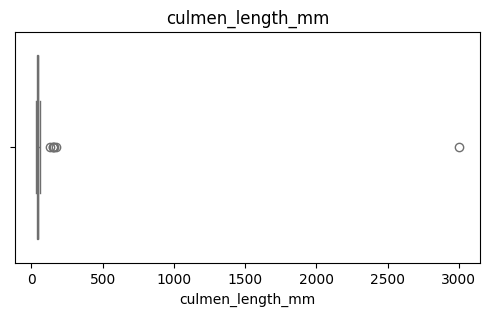

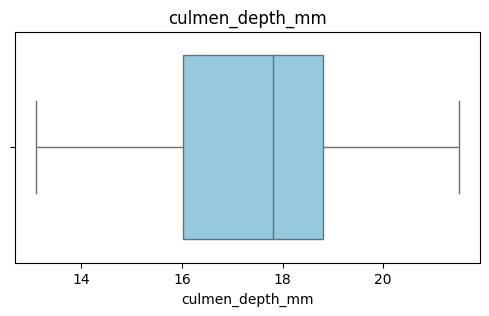

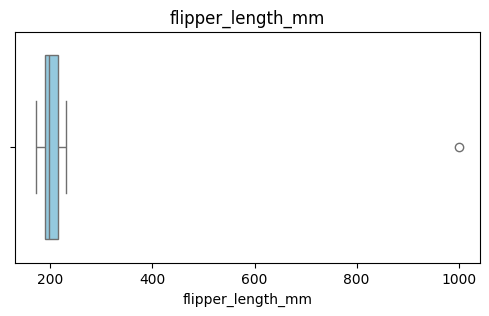

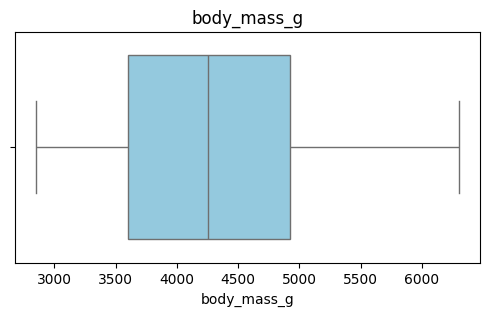

In [48]:
#checking for potential outlier data points 

numeric_cols = df.select_dtypes(include=['float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(col)
    plt.show()

1. Possibly faulty data entry found with outliers being in culmen length and flipper length 
2. Try evaluating algos including and excluding that data point 

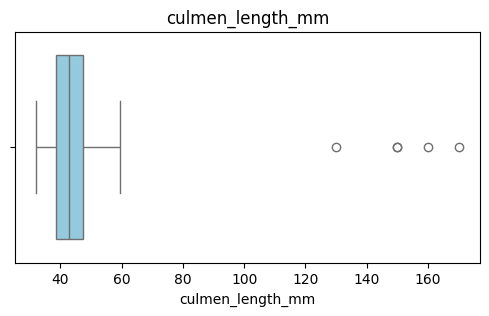

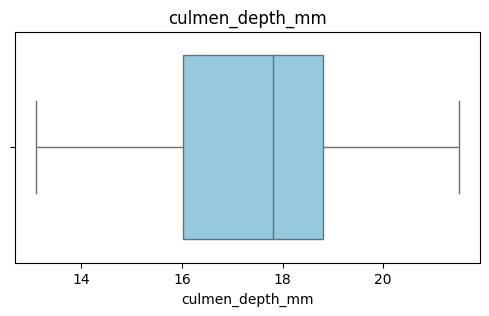

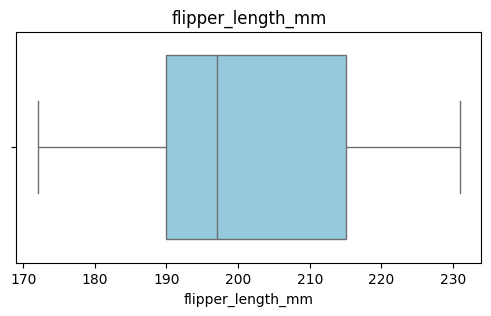

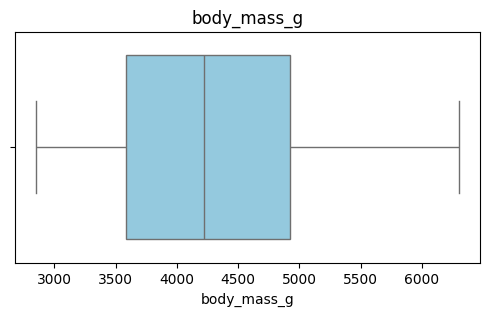

In [52]:
filtered_df = df[df['culmen_length_mm']!=3000]

numeric_cols = filtered_df.select_dtypes(include=['float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=filtered_df[col], color='skyblue')
    plt.title(col)
    plt.show()